In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

#from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re

import ipycytoscape
import torch

from pyvis.network import Network
import os
from datetime import datetime
import json

DEBUG = True
NOISE_RANGE = 0
SAVE_PATH = "Sim_Raw_data.parquet"
SAVE_PATH_GRAPH = 'Sim_Graph.json'

In [ ]:


def propagate_demand_upwards(G: nx.DiGraph, flow_attr='flow') -> nx.DiGraph:
    """
    Calculates flow for all edges in a DAG by propagating demand from 
    bottom leaf edges upwards to the top sources.
    
    Args:
        G: A NetworkX DiGraph (must be Acyclic).
           'Leaf edges' (edges pointing to nodes with out_degree=0) must 
           have the 'flow' attribute set.
        flow_attr: The attribute name for the flow value.
        
    Returns:
        The DiGraph with calculated flows on all edges.
    """
    # Work on a copy to preserve original structure
    H = G.copy()

    # 1. Verification: Ensure it is a DAG (Cycles break Kirchhoff's logic)
    if not nx.is_directed_acyclic_graph(H):
        raise ValueError("Graph contains a cycle. Kirchhoff propagation requires a DAG.")

    # 2. Initialize flow on non-leaf edges to 0 to be safe
    for u, v, data in H.edges(data=True):
        if flow_attr not in data:
            data[flow_attr] = 0.0

    # 3. Get Reverse Topological Sort
    # We process children before parents.
    # The last nodes in a topo sort are the leaves; reversed means we start with them.
    try:
        nodes_bottom_up = list(reversed(list(nx.topological_sort(H))))
    except nx.NetworkXUnfeasible:
        raise ValueError("Graph cycle detected during sort.")

    # 4. Propagate Flow Upwards
    for node in nodes_bottom_up:
        # Step A: Calculate how much this node OUTPUTS (Demand)
        out_edges = H.out_edges(node, data=True)
        
        # If it's a leaf node, it doesn't output to other nodes, 
        # but the edges *entering* it carry the flow we start with.
        # We need to calculate the flow for the edges ENTERING this node.
        
        # Calculate the total flow leaving this node
        total_out_flow = sum(data.get(flow_attr, 0.0) for _, _, data in out_edges)
        
        # NOTE: If this is a true "Leaf" (out_degree=0), total_out_flow is 0.
        # But wait - the prompt says "flow is attribute in the LEAF EDGES".
        # This implies the edges *entering* the leaves already have values.
        # So we actually need to process 'Internal Nodes' that feed these leaves.
        
        # If total_out_flow is 0, check if this node is a sink that was manually set?
        # No, the flow is on the *edge*. 
        # So if I am Node B, and I point to Leaf C (B->C), B->C has flow.
        # I just summed B->C. Now I need to supply B's parents.

        # Step B: Identify Parents (Incoming Edges)
        in_edges = list(H.in_edges(node))
        num_parents = len(in_edges)

        if num_parents > 0:
            # If the node has output flow, it must request that amount from inputs.
            # However, if this node is a Leaf, it has NO output edges.
            # But the edge pointing TO it (Parent->Leaf) is the one with the value.
            # We don't need to calculate the flow for the edge pointing to the leaf 
            # (it's already there). We need to calculate the flow for the Parent's Parent.
            
            # So, strictly speaking, we only need to act if we are an INTERNAL node
            # whose out-edges have just been summed up.
            
            # If total_out_flow > 0, we propagate it up.
            if total_out_flow > 0:
                flow_per_parent = total_out_flow / num_parents
                
                for parent, _ in in_edges:
                    # Set the flow for the incoming edge (Parent -> Node)
                    # We use += because a parent might have multiple children 
                    # causing it to accumulate demand from different branches.
                    # BUT: Since we initialize to 0 and visit each edge once from the child side,
                    # we can technically just set it, but += is safer for aggregation logic.
                    
                    current_val = H[parent][node].get(flow_attr, 0.0)
                    
                    # If this edge was a "leaf edge" preset by the user, we shouldn't overwrite it?
                    # The user said leaf edges have attributes. Upper edges don't.
                    # We only overwrite if it's 0 (calculated).
                    if current_val == 0.0:
                         H[parent][node][flow_attr] = flow_per_parent
                    else:
                        # If the edge already has flow (e.g., it's a leaf edge), 
                        # we use that value for the sum, but we don't change it.
                        pass

    return H

def draw_flow_graph_spaced(G, flow_attr='flow', spacing=2.0):
    plt.figure(figsize=(8 * spacing, 6 * spacing))
    
    # 1. Layout logic
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes: 
            G.nodes[node]['layer'] = layer
    pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal', scale=spacing)

    # 2. Identify Nodes
    leaf_nodes = [n for n, d in G.out_degree() if d == 0]
    regular_nodes = [n for n in G.nodes() if n not in leaf_nodes]

    # 3. Draw Nodes (Draw these first)
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, node_size=2500, node_color='white', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_size=2500, node_color='lightgreen', edgecolors='darkgreen')
    nx.draw_networkx_labels(G, pos, font_size=12)

    # 4. Draw Edges (PUT ARROWS HERE)
    nx.draw_networkx_edges(
        G, pos, 
        node_size=2500,          # Tells arrows where to stop so they are visible
        arrows=True,              # Valid here
        arrowstyle='-|>',         # Solid triangle head
        arrowsize=40,             # Large enough to see
        edge_color='#555555', 
        width=2,
        min_target_margin=25      # Forces the arrow tip to stay outside the node circle
    )

    # 5. Draw Edge Labels (TEXT ONLY)
    edge_labels = {
        (u, v): f"{d[flow_attr]:.1f}" 
        for u, v, d in G.edges(data=True) if flow_attr in d
    }
    
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, # No 'arrows' or 'arrow' argument here!
        font_color='darkred', 
        font_size=11, 
        font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )

    plt.axis('off')
    plt.show()

def draw_flow_graph_spaced_df(G,df):

    _attr = df.columns[-1]
    print(_attr)
   
    _h = nx.from_pandas_edgelist(df, 
                            source=0, 
                            target=1, 
                            edge_attr=True, 
                            create_using=nx.DiGraph()
                            )

    draw_flow_graph_spaced(_h, flow_attr=_attr)
    
def reconsruct_flows(G, flows:dict):
    H = G.copy()

    for _leaf_node,_flow in flows.items():
        _edge_leaf = [x for x in H.edges() if x[1] == _leaf_node]
        H.edges[_edge_leaf[0]]["flow"] = float(_flow)

    H = propagate_demand_upwards(H)
    return H




# CREATE THE GRAPH

In [2]:

G_router = nx.DiGraph()
G_router.add_edge('HR_A', 'MR_A', capacity=10000)
G_router.add_edge('HR_B', 'MR_B', capacity=10000)
G_router.add_edge('MR_B', 'MR_A', capacity=10000)
G_router.add_edge('MR_A', 'C', capacity=10000)

G_router.add_edge('C', 'D', capacity=10000)
G_router.add_edge('MR_B', 'A', capacity=10000)
G_router.add_edge('A', 'B', capacity=10000)
G_router.add_edge('B', 'D', capacity=10000)
G_router.add_edge('D', 'E', capacity=10000)

G_router.add_edge('C', 'S7', capacity=10000)
G_router.add_edge('D', 'S6', capacity=10000)
G_router.add_edge('D', 'S5', capacity=10000)
G_router.add_edge('B', 'S3', capacity=10000)
G_router.add_edge('A', 'S1', capacity=10000)
G_router.add_edge('A', 'S2', capacity=10000)
G_router.add_edge('E', 'S4', capacity=10000)



G_links_raw = nx.line_graph(G_router)

G_links = nx.DiGraph()
for _edge in G_links_raw.edges():
    G_links.add_edge('-'.join(_edge[0]), '-'.join(_edge[1]) )



print(f"Nodes: {G_links.nodes()}")
print(f"Edges: {G_links.edges()}")

Nodes: ['HR_A-MR_A', 'MR_A-C', 'C-D', 'C-S7', 'D-E', 'D-S6', 'D-S5', 'HR_B-MR_B', 'MR_B-MR_A', 'MR_B-A', 'A-B', 'A-S1', 'A-S2', 'B-D', 'B-S3', 'E-S4']
Edges: [('HR_A-MR_A', 'MR_A-C'), ('MR_A-C', 'C-D'), ('MR_A-C', 'C-S7'), ('C-D', 'D-E'), ('C-D', 'D-S6'), ('C-D', 'D-S5'), ('D-E', 'E-S4'), ('HR_B-MR_B', 'MR_B-MR_A'), ('HR_B-MR_B', 'MR_B-A'), ('MR_B-MR_A', 'MR_A-C'), ('MR_B-A', 'A-B'), ('MR_B-A', 'A-S1'), ('MR_B-A', 'A-S2'), ('A-B', 'B-D'), ('A-B', 'B-S3'), ('B-D', 'D-E'), ('B-D', 'D-S6'), ('B-D', 'D-S5')]


# CREATING DEMANDS

In [3]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)
    
def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve



DEMANDS_NODES = [x for x in G_links.nodes() if re.match(r'.*-S\d+', x)]
print(f"Nodes con demanda: {DEMANDS_NODES}")
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')

DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
DEMANDS

Nodes con demanda: ['C-S7', 'D-S6', 'D-S5', 'A-S1', 'A-S2', 'B-S3', 'E-S4']


,C-S7,D-S6,D-S5,A-S1,A-S2,B-S3,E-S4
2024-01-01 00:00:00,0.130952,0.270742,0.231672,0.311042,0.280811,0.822289,0.684298
2024-01-01 01:00:00,0.000000,0.406114,0.231672,0.311042,0.140406,0.352410,0.570248
2024-01-01 02:00:00,0.523810,0.135371,0.231672,0.155521,0.561622,0.469880,0.684298
2024-01-01 03:00:00,0.654762,0.135371,0.463343,0.622084,0.842434,0.822289,0.912397
2024-01-01 04:00:00,0.916667,0.406114,1.853372,1.555210,0.421217,0.469880,2.166942
...,...,...,...,...,...,...,...
2024-06-28 19:00:00,56.030050,66.569343,65.331933,75.000000,67.325243,58.485149,69.763583
2024-06-28 20:00:00,36.435726,30.510949,73.000000,57.843750,46.446602,41.059406,40.817915
2024-06-28 21:00:00,16.355593,12.116788,54.289916,26.437500,24.451456,19.277228,17.186490
2024-06-28 22:00:00,5.343907,1.897810,20.039216,6.093750,9.601942,5.336634,4.748899


# RECONTRUCT THE EDGES

In [4]:
def calculate_upward_flow(G, leaf_flows):
    """
    G: A directed acyclic graph (DAG).
    leaf_flows: A dict {node: flow_value} for the starting leaf nodes.
    """
    # 1. Initialize all node and edge flows to 0
    node_flows = {node: 0.0 for node in G.nodes()}
    edge_flows = {}

    # 2. Assign initial flows to the leaf nodes
    for node, flow in leaf_flows.items():
        node_flows[node] = flow

    # 3. Get Reverse Topological Order (Bottom-Up)
    # This ensures children are processed before parents
    nodes_bottom_up = list(nx.topological_sort(G))[::-1]

    for v in nodes_bottom_up:
        # The flow leaving this node is its accumulated node_flow
        current_flow = node_flows[v]
        
        # Get predecessors (the "upward" targets)
        preds = list(G.predecessors(v))
        
        if preds:
            # Distribute the flow to predecessors
            # Here we split it equally, but you could use edge weights
            flow_per_pred = current_flow / len(preds)
            
            for u in preds:
                edge_flows[(u, v)] = flow_per_pred
                node_flows[u] += flow_per_pred

    return node_flows, edge_flows


RAW_DATA = []
for _date,_flows in DEMANDS.iterrows():
    _flow_node, _flow_egde = calculate_upward_flow(G_links,_flows.to_dict())
    _row = pd.DataFrame(_flow_node, index=[_date])
    RAW_DATA.append(_row)
    
RAW_DATA = pd.concat(RAW_DATA)
RAW_DATA

,HR_A-MR_A,MR_A-C,C-D,C-S7,D-E,D-S6,D-S5,HR_B-MR_B,MR_B-MR_A,MR_B-A,A-B,A-S1,A-S2,B-D,B-S3,E-S4
2024-01-01 00:00:00,0.362154,0.724308,0.593356,0.130952,0.684298,0.270742,0.231672,2.369652,0.362154,2.007498,1.415645,0.311042,0.280811,0.593356,0.822289,0.684298
2024-01-01 01:00:00,0.302008,0.604017,0.604017,0.000000,0.570248,0.406114,0.231672,1.709882,0.302008,1.407874,0.956426,0.311042,0.140406,0.604017,0.352410,0.570248
2024-01-01 02:00:00,0.524740,1.049480,0.525670,0.523810,0.684298,0.135371,0.231672,2.237433,0.524740,1.712693,0.995550,0.155521,0.561622,0.525670,0.469880,0.684298
2024-01-01 03:00:00,0.705159,1.410317,0.755555,0.654762,0.912397,0.135371,0.463343,3.747521,0.705159,3.042362,1.577845,0.622084,0.842434,0.755555,0.822289,0.912397
2024-01-01 04:00:00,1.564940,3.129881,2.213214,0.916667,2.166942,0.406114,1.853372,6.224461,1.564940,4.659520,2.683094,1.555210,0.421217,2.213214,0.469880,2.166942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,78.431240,156.862479,100.832429,56.030050,69.763583,66.569343,65.331933,380.074060,78.431240,301.642821,159.317578,75.000000,67.325243,100.832429,58.485149,69.763583
2024-06-28 20:00:00,54.300079,108.600158,72.164432,36.435726,40.817915,30.510949,73.000000,271.814269,54.300079,217.514190,113.223838,57.843750,46.446602,72.164432,41.059406,40.817915
2024-06-28 21:00:00,29.076095,58.152190,41.796597,16.355593,17.186490,12.116788,54.289916,141.038876,29.076095,111.962781,61.073825,26.437500,24.451456,41.796597,19.277228,17.186490
2024-06-28 22:00:00,9.343434,18.686869,13.342962,5.343907,4.748899,1.897810,20.039216,43.718722,9.343434,34.375288,18.679596,6.093750,9.601942,13.342962,5.336634,4.748899


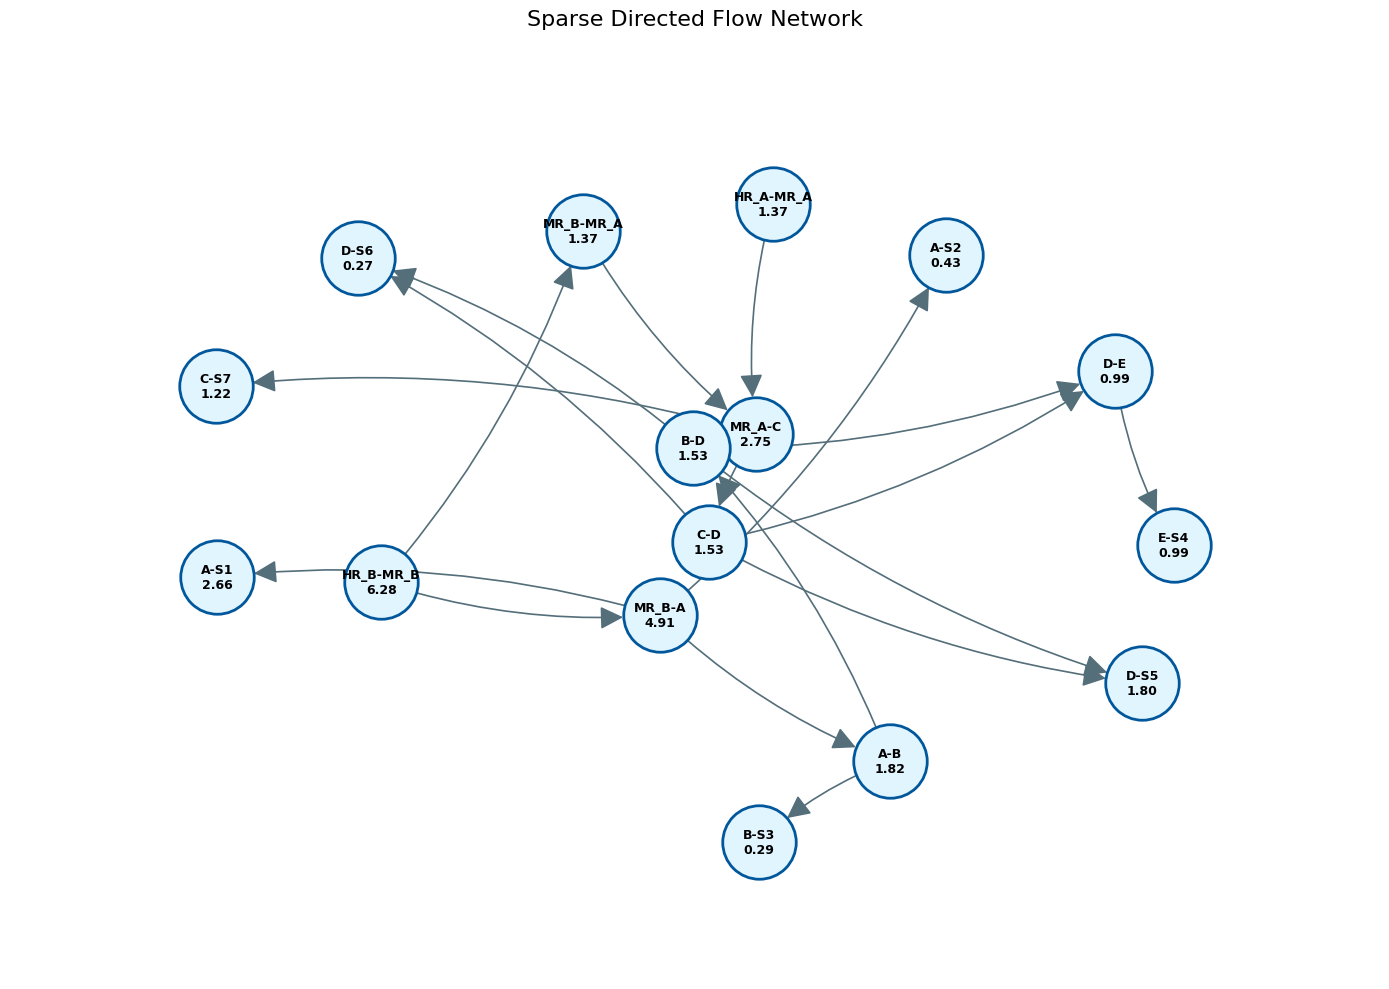

In [5]:
def display_sparse_flow_graph(G, node_values):
    """
    Displays a DiGraph with a very sparse layout and clear directions.
    """
    plt.figure(figsize=(14, 10)) # Increased figure size for more breathing room
    
    # k: The optimal distance between nodes. Increase this for more sparsity.
    # Default is approx 1/sqrt(n). Setting it to 2.0+ makes it very sparse.
    pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)
    
    # 1. Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, 
        node_size=2800, # Slightly larger for better label fitting
        node_color='#E1F5FE', 
        edgecolors='#01579B',
        linewidths=2
    )
    
    # 2. Draw Edges with corrected arrowstyle and node_size clipping
    nx.draw_networkx_edges(
        G, pos, 
        arrows=True, 
        arrowstyle='-|>', 
        arrowsize=35, 
        edge_color='#546E7A',
        width=1.2,
        connectionstyle='arc3,rad=0.1',
        node_size=2800 # Match node_size to ensure arrows stop at the border
    )
    
    # 3. Add Labels
    labels = {n: f"{n}\n{node_values.get(n, 0):.2f}" for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

    plt.title("Sparse Directed Flow Network", fontsize=16, pad=30)
    plt.axis('off')
    
    # Use margins to ensure nodes near the edge aren't cut off
    plt.margins(0.15) 
    plt.tight_layout()
    plt.show()



display_sparse_flow_graph(G_links, RAW_DATA.sample(1).to_dict('records')[0])

In [6]:

############################################## SIULATING NOISE ################################
if NOISE_RANGE > 0:
    NOISE =  np.random.uniform(-NOISE_RANGE, NOISE_RANGE,size=RAW_DATA.shape)
else:
    NOISE = 0
    
RAW_DATA = RAW_DATA*(1+NOISE)
RAW_DATA = RAW_DATA.T



## PREPARATION OF DATA

In [7]:
SAMPLING = '1h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS = TSS[np.array(G_links.nodes())]
TSS

,HR_A-MR_A,MR_A-C,C-D,C-S7,D-E,D-S6,D-S5,HR_B-MR_B,MR_B-MR_A,MR_B-A,A-B,A-S1,A-S2,B-D,B-S3,E-S4
2024-01-01 00:00:00,0.362154,0.724308,0.593356,0.130952,0.684298,0.270742,0.231672,2.369652,0.362154,2.007498,1.415645,0.311042,0.280811,0.593356,0.822289,0.684298
2024-01-01 01:00:00,0.302008,0.604017,0.604017,0.000000,0.570248,0.406114,0.231672,1.709882,0.302008,1.407874,0.956426,0.311042,0.140406,0.604017,0.352410,0.570248
2024-01-01 02:00:00,0.524740,1.049480,0.525670,0.523810,0.684298,0.135371,0.231672,2.237433,0.524740,1.712693,0.995550,0.155521,0.561622,0.525670,0.469880,0.684298
2024-01-01 03:00:00,0.705159,1.410317,0.755555,0.654762,0.912397,0.135371,0.463343,3.747521,0.705159,3.042362,1.577845,0.622084,0.842434,0.755555,0.822289,0.912397
2024-01-01 04:00:00,1.564940,3.129881,2.213214,0.916667,2.166942,0.406114,1.853372,6.224461,1.564940,4.659520,2.683094,1.555210,0.421217,2.213214,0.469880,2.166942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,78.431240,156.862479,100.832429,56.030050,69.763583,66.569343,65.331933,380.074060,78.431240,301.642821,159.317578,75.000000,67.325243,100.832429,58.485149,69.763583
2024-06-28 20:00:00,54.300079,108.600158,72.164432,36.435726,40.817915,30.510949,73.000000,271.814269,54.300079,217.514190,113.223838,57.843750,46.446602,72.164432,41.059406,40.817915
2024-06-28 21:00:00,29.076095,58.152190,41.796597,16.355593,17.186490,12.116788,54.289916,141.038876,29.076095,111.962781,61.073825,26.437500,24.451456,41.796597,19.277228,17.186490
2024-06-28 22:00:00,9.343434,18.686869,13.342962,5.343907,4.748899,1.897810,20.039216,43.718722,9.343434,34.375288,18.679596,6.093750,9.601942,13.342962,5.336634,4.748899


<Axes: >

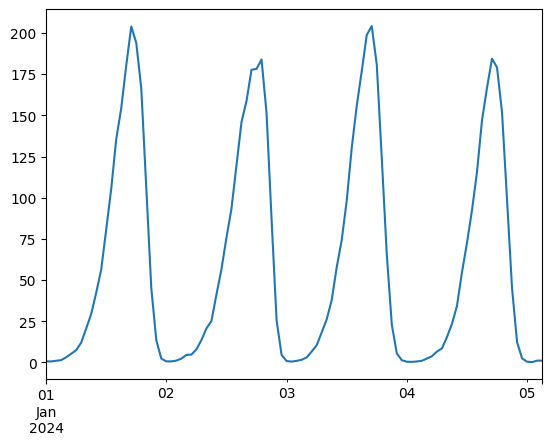

In [15]:
TSS[['C-D','C-S7']].sum(axis=1).iloc[0:100].plot()

<Axes: >

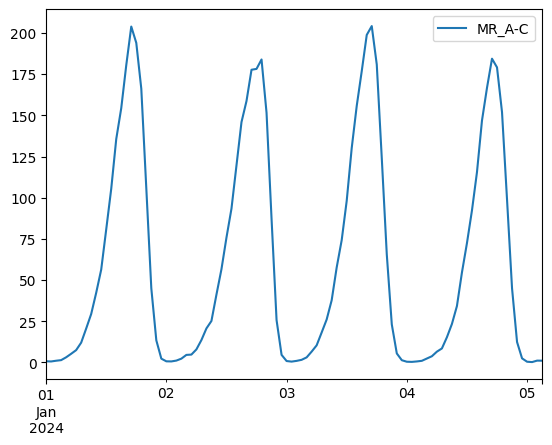

In [13]:
TSS[['MR_A-C']].iloc[0:100].plot()

In [18]:
print(f"Saving Data in {SAVE_PATH}")
RAW_DATA.to_parquet(SAVE_PATH)

Saving Data in Sim_Raw_data.parquet


In [20]:
import json

def save_graph_to_json(G, filename):
    # Convert the graph to a JSON-serializable dictionary
    data = nx.node_link_data(G)
    
    with open(filename, 'w') as f:
        json.dump(data, f, indent=4)
    print(f"Graph saved to {filename}")

save_graph_to_json(G_links, SAVE_PATH_GRAPH)

Graph saved to Sim_Graph.json
